![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

In [2]:
# QuantBook Analysis Tool 
# For more information see [https://www.quantconnect.com/docs/v2/our-platform/research/getting-started]
qb = QuantBook()
sy = qb.add_crypto("BTCUSD", Resolution.MINUTE)
# Locally Lean installs free sample data, to download more data please visit https://www.quantconnect.com/docs/v2/lean-cli/datasets/downloading-data 
qb.set_start_date(2026, 2, 22)

In [3]:
sy.symbol

In [4]:
from datetime import datetime

In [5]:
df = qb.history(sy.symbol, datetime(2017, 1, 1), datetime(2026, 1, 5))

In [6]:
len(df)

4739040

In [7]:
df = df.reset_index()
df

,symbol,time,askclose,askhigh,asklow,askopen,asksize,bidclose,bidhigh,bidlow,bidopen,bidsize,close,high,low,open,volume
0,BTCUSD,2017-01-01 05:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,967.73,968.10,967.73,968.10,0.309496
1,BTCUSD,2017-01-01 05:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,967.29,967.73,967.29,967.73,10.000000
2,BTCUSD,2017-01-01 05:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,966.61,967.30,966.61,967.30,10.000000
3,BTCUSD,2017-01-01 05:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,966.03,967.09,966.03,966.95,10.000000
4,BTCUSD,2017-01-01 05:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,966.58,966.58,965.77,966.38,3.423130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4739035,BTCUSD,2026-01-05 04:56:00,6782.61,6782.61,6782.61,6782.61,70.152113,6782.6,6782.6,6782.6,6782.6,2.261653,92579.90,92591.40,92536.00,92536.00,3.510152
4739036,BTCUSD,2026-01-05 04:57:00,6782.61,6782.61,6782.61,6782.61,70.152113,6782.6,6782.6,6782.6,6782.6,2.261653,92592.00,92631.93,92544.00,92578.01,6.764581
4739037,BTCUSD,2026-01-05 04:58:00,6782.61,6782.61,6782.61,6782.61,70.152113,6782.6,6782.6,6782.6,6782.6,2.261653,92598.00,92611.40,92586.00,92592.00,0.661447
4739038,BTCUSD,2026-01-05 04:59:00,6782.61,6782.61,6782.61,6782.61,70.152113,6782.6,6782.6,6782.6,6782.6,2.261653,92599.98,92599.98,92570.83,92596.01,0.762734


In [8]:
import pandas as pd

def analyze_time_gaps(df, time_col='time', expected_freq='1min'):
    """
    Analyzes a DataFrame for missing time gaps based on an expected frequency.
    """
    # 1. Ensure the column is datetime type and sorted chronologically
    df_sorted = df.copy()
    df_sorted[time_col] = pd.to_datetime(df_sorted[time_col])
    df_sorted = df_sorted.sort_values(by=time_col).reset_index(drop=True)
    
    # 2. Calculate the difference between consecutive timestamps
    time_diffs = df_sorted[time_col].diff()
    
    # 3. Identify where the difference is strictly greater than the expected 1 minute
    expected_delta = pd.Timedelta(expected_freq)
    gap_mask = time_diffs > expected_delta
    
    # If no gaps are found, return an empty DataFrame
    if not gap_mask.any():
        print("No gaps found!")
        return pd.DataFrame()
    
    # 4. Extract gap details
    # The gap "ends" at the row where the condition is True
    gap_ends = df_sorted.loc[gap_mask, time_col].reset_index(drop=True)
    
    # The gap "starts" at the row immediately before it
    gap_start_indices = df_sorted[gap_mask].index - 1
    gap_starts = df_sorted.loc[gap_start_indices, time_col].reset_index(drop=True)
    
    # The duration is the calculated time difference
    durations = time_diffs[gap_mask].reset_index(drop=True)
    
    # 5. Compile into a neat summary DataFrame
    gaps_summary = pd.DataFrame({
        'gap_start_time': gap_starts,
        'gap_end_time': gap_ends,
        'missing_duration': durations,
        'missing_minutes': (durations.dt.total_seconds() / 60) - 1 # Subtract 1 because a 2-min diff = 1 missing minute
    })
    
    print(f"Total gaps found: {len(gaps_summary)}")
    return gaps_summary

# ==========================================
# Example Usage:
# ==========================================

# Run the analysis
gaps_df = analyze_time_gaps(df, time_col='time')
print(gaps_df)

No gaps found!
Empty DataFrame
Columns: []
Index: []


In [9]:
len(df) / 60 / 24

3291.0

In [10]:
datetime(2026, 1, 5) - datetime(2017, 1, 1)  

datetime.timedelta(days=3291)

In [11]:
df.time.min(), df.time.max()

(Timestamp('2017-01-01 05:01:00'), Timestamp('2026-01-05 05:00:00'))

<Axes: >

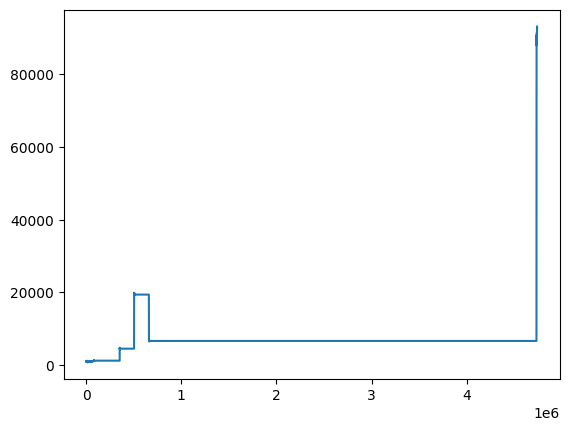

In [12]:
df.close.plot()

In [13]:
df.close

0            967.73
1            967.29
2            966.61
3            966.03
4            966.58
             ...   
4739035    92579.90
4739036    92592.00
4739037    92598.00
4739038    92599.98
4739039    92559.84
Name: close, Length: 4739040, dtype: float64